In [106]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [107]:
data = pd.read_csv('smartwatches.csv', index_col=[0])
data.head()

,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight
0,noise,82990.0,89900.0,7.686318,4.0,65.0,Wrb-sw-colorfitpro4alpha-std-rgld_pnk,NaN,NaN,NaN,NaN,8.0,Yes,NaN,35 - 50 g
1,fire-boltt,3799.0,16999.0,77.651627,4.3,20788.0,BSW046,NaN,NaN,Silicon,Yes,3.5,Yes,1.8 inches,50 - 75 g
2,boat,1999.0,7990.0,74.981227,3.8,21724.0,Wave Call,NaN,NaN,Silicon,Yes,8.0,Yes,1.7 inches,35 - 50 g
3,fire-boltt,1799.0,19999.0,91.004550,4.3,13244.0,BSW053,NaN,NaN,Silicon,Yes,3.5,Yes,1.8 inches,75g +
4,noise,1599.0,4999.0,68.013603,4.1,13901.0,Wrb-sw-colorfitpulsegobuzz-std-blk_blk,NaN,NaN,Other,Yes,8.0,Yes,1.7 inches,35 - 50 g


In [108]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brand                450 non-null    str    
 1   Current Price        440 non-null    float64
 2   Original Price       377 non-null    float64
 3   Discount Percentage  377 non-null    float64
 4   Rating               444 non-null    float64
 5   Number OF Ratings    391 non-null    float64
 6   Model Name           415 non-null    str    
 7   Dial Shape           327 non-null    str    
 8   Strap Color          327 non-null    str    
 9   Strap Material       381 non-null    str    
 10  Touchscreen          413 non-null    str    
 11  Battery Life (Days)  418 non-null    float64
 12  Bluetooth            444 non-null    str    
 13  Display Size         420 non-null    str    
 14  Weight               264 non-null    str    
dtypes: float64(6), str(9)
memory usage: 52.9 KB


In [109]:
data.describe()

,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Battery Life (Days)
count,440.000000,377.000000,377.000000,444.000000,391.000000,418.000000
mean,12747.554545,14598.204244,48.236894,4.031306,11594.726343,14.077392
std,17760.666099,15450.028869,24.109830,0.550548,40423.889227,7.718503
min,1199.000000,1669.000000,-79.688436,1.000000,1.000000,0.750000
25%,2180.750000,5999.000000,33.337037,3.900000,68.500000,8.000000
50%,3999.000000,7999.000000,54.550414,4.100000,996.000000,17.500000
75%,17121.750000,17999.000000,66.677780,4.300000,6022.000000,22.000000
max,139990.000000,96390.000000,91.004550,5.000000,619130.000000,22.000000


In [110]:
pd.DataFrame({
    'Columns': data.columns,
    'Missing_values': [data[i].isna().sum() for i in data.columns],
    'duplicate_values': [data[i].duplicated().sum() for i in data.columns]
    
})


,Columns,Missing_values,duplicate_values
0,Brand,0,432
1,Current Price,10,285
2,Original Price,73,345
3,Discount Percentage,73,178
4,Rating,6,422
5,Number OF Ratings,59,199
6,Model Name,35,60
7,Dial Shape,123,443
8,Strap Color,123,419
9,Strap Material,69,434


In [111]:
# Change dtype of Display size

data.loc[:, "Display Size"] = data.loc[:,'Display Size'].str.strip('inches')
data['Display Size'] = data['Display Size'].astype('float')

In [112]:
# Imputing missing values on a Categorical col. based on most freq val in their respective Brand in each col.

categorical_mode = data.groupby('Brand')[
    data.select_dtypes(include='object') # select all col with dtype object
    .columns.drop(['Brand']) # excluding Brand
    ].agg(lambda x:x.mode().iloc[0] if not x.mode().empty else np.nan) # Impute a mode in each col

categorical_mode

C:\Users\bhave\AppData\Local\Temp\ipykernel_30352\421939513.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include='object') # select all col with dtype object


,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Bluetooth,Weight
Brand,,,,,,,
amazfit,Bip 3 Pro with 1.69 inch Large Color Display Built-in GPS,Circle,Black,Silicon,Yes,Yes,<= 20 g
ambrane,FitShot Curl,Square,Black,Silicon,Yes,Yes,35 - 50 g
apple,Apple Watch SE,Rectangle,Black,Silicon,Yes,Yes,<= 20 g
boat,Watch Flash,Rectangle,Black,Silicon,Yes,Yes,35 - 50 g
crossbeats,S4 Max,NaN,NaN,NaN,Yes,Yes,20 - 35 g
dizo,D TALK SMART WATCH (SILVER GREY),Rectangle,Black,Silicon,Yes,Yes,20 - 35 g
fire-boltt,beast pro,Square,Black,Silicon,Yes,Yes,75g +
fitbit,Blaze,Square,Black,Silicon,Yes,Yes,20 - 35 g
fossil,4th Gen Explorist HR,Circle,Black,Stainless Steel,Yes,Yes,75g +


In [113]:
# Imputing missing values on Numerical col.

numerical_median = data.groupby('Brand')[
    data.select_dtypes(include = np.number)
    .columns].median()

numerical_median

,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Battery Life (Days),Display Size
Brand,,,,,,,
amazfit,8249.0,15999.0,29.585441,4.15,575.0,8.00,1.40
ambrane,1799.0,4999.0,60.542248,4.20,2475.0,22.00,1.70
apple,41900.0,31400.0,1.570780,4.60,2847.0,22.00,1.60
boat,1999.0,6990.0,74.263233,4.00,19590.0,22.00,1.70
crossbeats,3999.0,10999.0,63.338111,4.10,2426.0,5.80,1.85
dizo,2749.0,5999.0,47.510002,4.10,663.0,22.00,1.80
fire-boltt,3299.0,9999.0,65.006501,3.70,2571.0,22.00,1.45
fitbit,18849.0,22249.0,15.348749,4.60,396.5,10.50,1.30
fossil,14995.0,21995.0,39.405881,4.00,112.5,17.50,1.30


In [114]:
# fill all missing values with their respective brand mode and median

obj = 0
no = 0
# Not used because categorical col show str rather than object
# for col in data.columns.drop('Brand'): 
#     if data[col].dtype == 'o':
#         data[col] = data[col].fillna(data['Brand'].map(categorical_mode[col]))
#         obj+=1

#     elif np.issubdtype(data[col].dtype, np.number):
#         data[col] = data[col].fillna(data['Brand'].map(numerical_median[col]))
#         no += 1

for col in data.columns.drop('Brand'):
    if pd.api.types.is_string_dtype(data[col]):
        data[col] = data[col].fillna(data['Brand'].map(categorical_mode[col]))
        obj += 1
    elif pd.api.types.is_numeric_dtype(data[col]):
        data[col] = data[col].fillna(data['Brand'].map(numerical_median[col]))
        no += 1

print(f"Total number of object columns affected: {obj} \n"
    f"Total number of numeric columns affected: {no}")


Total number of object columns affected: 7 
Total number of numeric columns affected: 7


In [115]:
data.head()

,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight
0,noise,82990.0,89900.0,7.686318,4.0,65.0,Wrb-sw-colorfitpro4alpha-std-rgld_pnk,Rectangle,Black,Other,Yes,8.0,Yes,1.7,35 - 50 g
1,fire-boltt,3799.0,16999.0,77.651627,4.3,20788.0,BSW046,Square,Black,Silicon,Yes,3.5,Yes,1.8,50 - 75 g
2,boat,1999.0,7990.0,74.981227,3.8,21724.0,Wave Call,Rectangle,Black,Silicon,Yes,8.0,Yes,1.7,35 - 50 g
3,fire-boltt,1799.0,19999.0,91.004550,4.3,13244.0,BSW053,Square,Black,Silicon,Yes,3.5,Yes,1.8,75g +
4,noise,1599.0,4999.0,68.013603,4.1,13901.0,Wrb-sw-colorfitpulsegobuzz-std-blk_blk,Rectangle,Black,Other,Yes,8.0,Yes,1.7,35 - 50 g


In [116]:
def check(data):
    dict={}
    for col in data.columns:
        dtype = data[col].dtypes
        valid_instances = data[col].count()
        unique = data[col].nunique()
        null_count = data[col].isnull().sum()
        duplicates = data[col].duplicated().sum()
        dict[col] = dtype,valid_instances,unique,null_count,duplicates
        data_check = pd.DataFrame(dict, index=["dtype","valid_instances","unique","sum_null","duplicates"]).T
    return data_check

check(data)

,dtype,valid_instances,unique,sum_null,duplicates
Brand,str,450,18,0,432
Current Price,float64,450,167,0,283
Original Price,float64,450,106,0,344
Discount Percentage,float64,450,276,0,174
Rating,float64,450,27,0,423
Number OF Ratings,float64,450,257,0,193
Model Name,str,449,389,1,60
Dial Shape,str,445,6,5,443
Strap Color,str,445,30,5,419
Strap Material,str,445,15,5,434


In [117]:
# remove duplicates
data.drop_duplicates(inplace=True)
data.reset_index(drop=True, inplace=True)

data.duplicated().sum() # 0

np.int64(0)

In [118]:
def check_unique(data):
    nunique = data.apply(lambda col: col.nunique())
    unique_values = data.apply(lambda col: col.unique())
    data_check = pd.DataFrame({
        'uni_count': nunique,
        'unique_values': unique_values
    })
    return data_check

check_unique(data)

,uni_count,unique_values
Brand,18,"[noise, fire-boltt, boat, honor, crossbeats, samsung, garmin, huawei, dizo, gizmore, ambrane, zebronics, pebble, hammer, apple, fitbit, amazfit, fossil]"
Current Price,167,"[82990.0, 3799.0, 1999.0, 1799.0, 1599.0, 1499.0, 3499.0, 2499.0, 2999.0, 2699.0, 1199.0, 2599.0, 1699.0, 1449.0, 1899.0, 2199.0, 11499.0, 14999.0, 8999.0, 5999.0, 11999.0, 18410.0, 24490.0, 17999.0, 18000.0, 16990.0, 27990.0, 39490.0, 18990.0, 34990.0, 20990.0, 78490.0, 26581.0, 16499.0, 6400.0, 2126.0, 2749.0, 3299.0, 4299.0, 1299.0, 2368.0, 4499.0, 3999.0, 2099.0, 2449.0, 1399.0, 3599.0, 2399.0, 2624.0, 1794.0, 29650.0, 37900.0, 23349.0, 33900.0, 89900.0, 55900.0, 44730.0, 41900.0, 29900.0, 49666.0, 53900.0, 49900.0, 48900.0, 32899.0, 22900.0, 44900.0, 40900.0, 32900.0, 73900.0, 2799.0, 2299.0, 12999.0, 13999.0, 4999.0, 9047.0, 7999.0, 10999.0, 12990.0, 27999.0, 35999.0, 22749.0, 32999.0, 44999.0, 34997.0, 49999.0, 24999.0, 31999.0, 16999.0, 17490.0, 28999.0, 27490.0, 19990.0, 30990.0, 29990.0, 11699.0, 20499.0, 17699.0, 20999.0, 26499.0, 19999.0, ...]"
Original Price,106,"[89900.0, 16999.0, 7990.0, 19999.0, 4999.0, 3999.0, 6499.0, 5999.0, 7999.0, 6990.0, 5990.0, 18999.0, 1868.0, 9773.0, 12499.0, 9999.0, 14999.0, 7473.0, 30990.0, 37999.0, 33999.0, 19990.0, 34999.0, 22490.0, 36490.0, 44990.0, 27990.0, 51990.0, 25990.0, 20490.0, 89460.0, 42513.0, 29999.0, 11999.0, 1669.0, 6999.0, 5499.0, 4499.0, 2199.0, 7499.0, 8499.0, 11499.0, 10999.0, 8999.0, 29900.0, 31400.0, 23900.0, 44900.0, 50900.0, 32900.0, 8990.0, 9799.0, 15999.0, 20999.0, 17999.0, 17333.0, 13999.0, 39999.0, 35999.0, 48999.0, 42999.0, 54999.0, 26999.0, 31999.0, 28490.0, 31990.0, 29989.0, 34490.0, 22249.0, 22999.0, 23499.0, 21499.0, 23999.0, 25999.0, 20990.0, 41990.0, 93990.0, 50490.0, 31490.0, 36990.0, 89990.0, 46990.0, 62490.0, 39490.0, 82990.0, 96390.0, 67990.0, 55990.0, 39990.0, 29990.0, 21990.0, 14990.0, 21995.0, 22995.0, 14995.0, 17995.0, 16495.0, 3499.0, 2999.0, 5299.0, ...]"
Discount Percentage,276,"[7.686318131, 77.65162657, 74.98122653, 91.00455023, 68.01360272, 62.51562891, 60.0120024, 55.01375344, 69.24142176, 66.67777963, 52.50656332, 41.67361227, 70.0140028, 64.01280256, 58.34305718, 50.00833472, 66.22027534, 68.72340426, 82.84692418, 74.26323319, 67.4718398, 75.69384835, 75.8096828, 70.78012002, 72.50906363, 39.47576188, -17.71948608, -17.66090249, -20.00160013, 70.0070007, 40.00266684, 60.00400027, -20.42017931, 61.28105841, 51.55135661, 18.60973511, 9.95997999, 48.56995914, 24.45531347, 23.29405317, 15.19371993, 32.15434084, 32.69859588, 19.23816853, 7.320644217, 12.26246367, 37.4755957, 45.00150005, 46.66222185, 64.56076013, -79.68843619, 47.510002189999994, 65.00650065, 38.57693956, 87.00870087, 82.00820082, 69.10347336, 73.34555759, 75.01250208, 78.75984498, 45.00750125, 47.36608135, 56.01120224, 18.1900864, 75.00937617, 72.31881828, 57.15102157, 40.00533404, 43.563339745, 42.67235631, 66.67222269, 50.00625078, 75.00750075, 73.7592199, 50.01250313, 71.18484528, 65.01625406, 69.57126707, 67.27884353, 71.43877697, 60.01000167, 83.76047006, 79.17326444, 77.57219652, 70.8392366, 86.84667614, 88.34069506, 78.8976553, 85.00708392, 0.836120401, 1.570779866, 2.305439331, 0.378619154, 2.424361493, 0.003039514, 4.184100418, 67.51687922, 42.86326618, 62.50781348, 64.29489927, ...]"
Rating,27,"[4.0, 4.3, 3.8, 4.1, 3.5, 4.2, 3.9, 3.6, 3.7, 4.4, 4.5, 5.0, 4.7, 2.4, 2.5, 2.7, 2.0, 3.0, 4.6, 3.4, 4.8, 3.3, 3.1, 1.0, 2.3, 2.9, 2.6]"
Number OF Ratings,257,"[65.0, 20788.0, 21724.0, 13244.0, 13901.0, 32704.0, 1018.0, 39479.0, 8765.0, 545.0, 281.0, 9081.0, 93075.0, 227.0, 5866.0, 71481.0, 27771.0, 2931.0, 827.0, 69803.0, 23498.0, 3944.0, 328.0, 19590.0, 406.0, 181.0, 20.0, 100.0, 674.0, 7792.0, 996.0, 323.0, 72.0, 5228.0, 312.0, 4339.0, 6.0, 19.0, 1.0, 38.0, 127.0, 7.0, 830.0, 7108.0, 49.0, 18.0, 2.0, 39274.0, 25784.0, 33415.0, 10.0, 37.0, 69.5, 5.0, 102.0, 3.0, 301.0, 256.0, 33012.0, 2138.0, 3563.0, 94.0, 725.0, 55.0, 3856.0, 2571.0, 516.0, 7386.0, 2452.0, 207.0, 3

In [119]:
# Detecting Outliers

from tabulate import tabulate

outliers = {}

for col in data.select_dtypes(include=np.number).columns:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3-q1
    lower_bound = q1-1.5*iqr
    upper_bound = q3+1.5*iqr

    col_outliers = data[(data[col]>upper_bound) | (data[col]<lower_bound)]
    outliers[col] = col_outliers

print("Summary Stats for smartwatches:")
print(tabulate(data.describe(),headers='keys',tablefmt='pretty'))

for col, outlier_data in outliers.items():
    if len(outlier_data) == 0:
        continue
    else:
        print(f"Outliers in {col}", len(outlier_data))
        print(tabulate(outlier_data,headers='keys',tablefmt='pretty'))

Summary Stats for smartwatches:
+-------+--------------------+--------------------+---------------------+--------------------+--------------------+---------------------+--------------------+
|       |   Current Price    |   Original Price   | Discount Percentage |       Rating       | Number OF Ratings  | Battery Life (Days) |    Display Size    |
+-------+--------------------+--------------------+---------------------+--------------------+--------------------+---------------------+--------------------+
| count |       440.0        |       440.0        |        440.0        |       440.0        |       440.0        |        439.0        |       440.0        |
| mean  | 13104.452272727272 | 16906.979545454546 |  43.08094525723182  | 4.031818181818182  | 10133.967045454545 | 14.097038724373578  | 2.1470454545454545 |
|  std  | 17861.66489668709  | 15609.239458008176 | 25.131434293899545  | 0.5535854255296769 | 38193.19469981024  |  7.663339483067651  | 4.283388520655802  |
|  min  |     

In [120]:

pd.reset_option('display.max_rows')

outliers.get('Display Size').sort_values('Display Size', ascending=False)

,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight
296,fossil,18995.0,21995.0,39.405881,4.0,102.0,Wander RG,Circle,Black,Silicon,Yes,22.0,Yes,45.0,75g +
50,garmin,39490.0,44990.0,15.193720,3.7,6.0,7.54E+11,Circle,Black,Silicon,Yes,22.0,Yes,35.9,35 - 50 g
52,garmin,39490.0,44990.0,15.193720,5.0,1.0,7.54E+11,Circle,Black,Silicon,Yes,22.0,Yes,35.9,35 - 50 g
247,garmin,39490.0,41990.0,5.953799,4.8,6.0,"Venu 2, GPS Smartwatch, AMOLED Display, Upto 11 Days Battery, SPO2 & Music",Circle,Blue,Silicon,Yes,17.5,Yes,33.0,20 - 35 g
54,garmin,39490.0,44990.0,15.193720,3.8,38.0,7.54E+11,Circle,Black,Stainless Steel,Yes,8.0,Yes,30.0,75g +
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,fire-boltt,3599.0,9999.0,64.006401,3.7,2571.0,ring,Square,Blue,Rubber,Yes,22.0,Yes,0.1,75g +
438,fire-boltt,3200.0,7999.0,59.994999,3.7,2571.0,call 2,Square,Blue,Silicon,Yes,22.0,Yes,0.1,75g +
436,fire-boltt,3700.0,9999.0,62.996300,3.7,2571.0,beast pro,Square,Black,Silicon,Yes,8.0,Yes,0.1,75g +
439,fire-boltt,3000.0,7999.0,62.495312,3.7,2571.0,call 2,Square,Black,Silicon,Yes,22.0,Yes,0.1,75g +


In [121]:
import plotly.express as px
fig = px.box(data_frame=data.select_dtypes(include=np.number),orientation="v")

fig.show()

In [122]:
data.head()

,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight
0,noise,82990.0,89900.0,7.686318,4.0,65.0,Wrb-sw-colorfitpro4alpha-std-rgld_pnk,Rectangle,Black,Other,Yes,8.0,Yes,1.7,35 - 50 g
1,fire-boltt,3799.0,16999.0,77.651627,4.3,20788.0,BSW046,Square,Black,Silicon,Yes,3.5,Yes,1.8,50 - 75 g
2,boat,1999.0,7990.0,74.981227,3.8,21724.0,Wave Call,Rectangle,Black,Silicon,Yes,8.0,Yes,1.7,35 - 50 g
3,fire-boltt,1799.0,19999.0,91.004550,4.3,13244.0,BSW053,Square,Black,Silicon,Yes,3.5,Yes,1.8,75g +
4,noise,1599.0,4999.0,68.013603,4.1,13901.0,Wrb-sw-colorfitpulsegobuzz-std-blk_blk,Rectangle,Black,Other,Yes,8.0,Yes,1.7,35 - 50 g


In [123]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
data[data.columns[data.eq("Yes").any()]] # equivalent to data[['Touchscreen', 'Bluetooth']]

,Touchscreen,Bluetooth
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
...,...,...
435,Yes,Yes
436,Yes,Yes
437,Yes,Yes
438,Yes,Yes


In [124]:
for col in data.columns[data.eq("Yes").any()]:
    le.fit(data[col])
    data[col] = le.transform(data[col])

In [125]:
pd.set_option('display.max_colwidth', None)

In [126]:
u = data.groupby(
    ["Brand","Model Name","Display Size","Weight"]
)[['Current Price']].nunique()

u_filtered = u[u["Current Price"] > 1].reset_index()

u_filtered = u_filtered.rename(
    columns={"Current Price": "Unique Price Count"}
)

result = pd.merge(
    data,
    u_filtered,
    on=["Brand","Model Name","Display Size","Weight"],
    how="inner"
)

result


,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight,Unique Price Count
0,boat,1999.0,7990.0,74.981227,3.6,827.0,Watch Flash,Rectangle,Black,Silicon,1,8.00,1,1.7,35 - 50 g,3
1,boat,1449.0,5990.0,75.809683,3.9,3944.0,Watch Flash,Rectangle,Black,Silicon,1,22.00,1,1.7,35 - 50 g,3
2,boat,1899.0,6499.0,70.780120,3.7,328.0,Watch Flash,Rectangle,Black,Silicon,1,8.00,1,1.7,35 - 50 g,3
3,samsung,24490.0,33999.0,18.609735,4.3,5228.0,Galaxy Watch 3 41 mm,Circle,Black,Fluoroelastomer,1,3.60,1,4.4,20 - 35 g,2
4,samsung,17999.0,19990.0,9.959980,4.3,5228.0,Galaxy Watch 3 41 mm,Circle,Black,Fluoroelastomer,1,3.60,1,4.4,20 - 35 g,2
5,garmin,27990.0,36490.0,23.294053,4.5,4339.0,7.54E+11,Circle,Black,Silicon,1,17.50,1,1.2,<= 20 g,4
6,garmin,18990.0,27990.0,32.154341,4.3,19.0,7.54E+11,Circle,Black,Silicon,1,17.50,1,1.2,<= 20 g,4
7,garmin,20990.0,25990.0,19.238169,4.3,127.0,7.54E+11,Circle,Black,Silicon,1,17.50,1,1.2,<= 20 g,4
8,garmin,78490.0,89460.0,12.262464,4.4,6.0,7.54E+11,Circle,Black,Silicon,1,17.50,1,1.2,<= 20 g,4
9,huawei,26581.0,42513.0,37.475596,4.7,830.0,Fit,Circle,Black,Silicon,1,8.00,1,1.4,35 - 50 g,2


In [127]:
# For various brands given in the dataset, with the same Model,
# the distinction might be noticed in either their display size, 
# weight or the colors of their part (Specifically Dial Shape).

# Otherwise, it hinges upon the discount on that specific product model.

In [128]:
data.groupby("Brand")['Model Name'].nunique().sort_values(ascending=False)

Brand
noise         41
fire-boltt    40
garmin        34
pebble        33
zebronics     31
apple         26
samsung       25
fossil        24
boat          22
gizmore       20
fitbit        20
dizo          19
amazfit       14
huawei        13
honor         13
ambrane       11
crossbeats     3
hammer         0
Name: Model Name, dtype: int64

In [129]:
data.groupby("Brand")["Current Price"].mean().sort_values(ascending=False)

Brand
garmin        44807.073171
apple         43161.307692
samsung       25284.666667
fitbit        17752.904762
fossil        15232.666667
huawei        15159.133333
honor         10373.857143
amazfit       10084.785714
crossbeats     4249.000000
noise          4029.023256
pebble         3648.242424
fire-boltt     3357.964286
dizo           3076.260870
zebronics      2725.454545
gizmore        2320.739130
boat           2161.500000
ambrane        1896.181818
hammer         1799.000000
Name: Current Price, dtype: float64

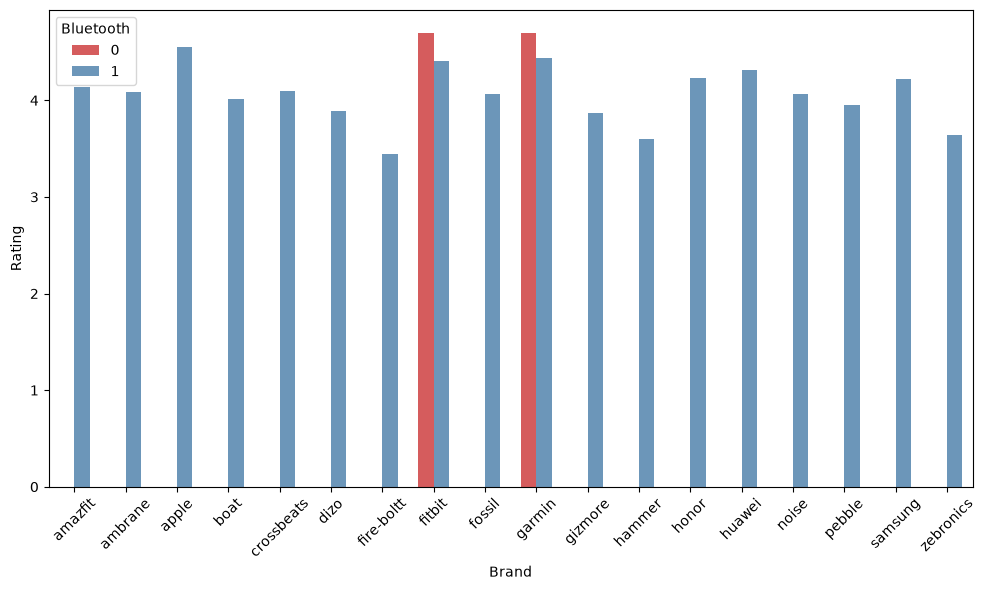

In [130]:
rating = data.groupby(['Brand','Bluetooth'])[['Rating']].mean()

plt.figure(figsize = (10, 6))
sns.barplot(data=rating, x='Brand', y = 'Rating', hue = "Bluetooth",
            palette = 'Set1', alpha = 0.8, width = 0.6)

plt.xticks(rotation = 45)
plt.tight_layout()

In [131]:
data.groupby(['Brand','Bluetooth'])[['Rating']].nunique()

Rating
Brand      Bluetooth        
amazfit    1               7
ambrane    1               5
apple      1               5
boat       1               8
crossbeats 1               2
dizo       1               9
fire-boltt 1              12
fitbit     0               1
           1               7
fossil     1               9
garmin     0               1
           1              14
gizmore    1              12
hammer     1               1
honor      1               5
huawei     1               7
noise      1               8
pebble     1              12
samsung    1               7
zebronics  1              12

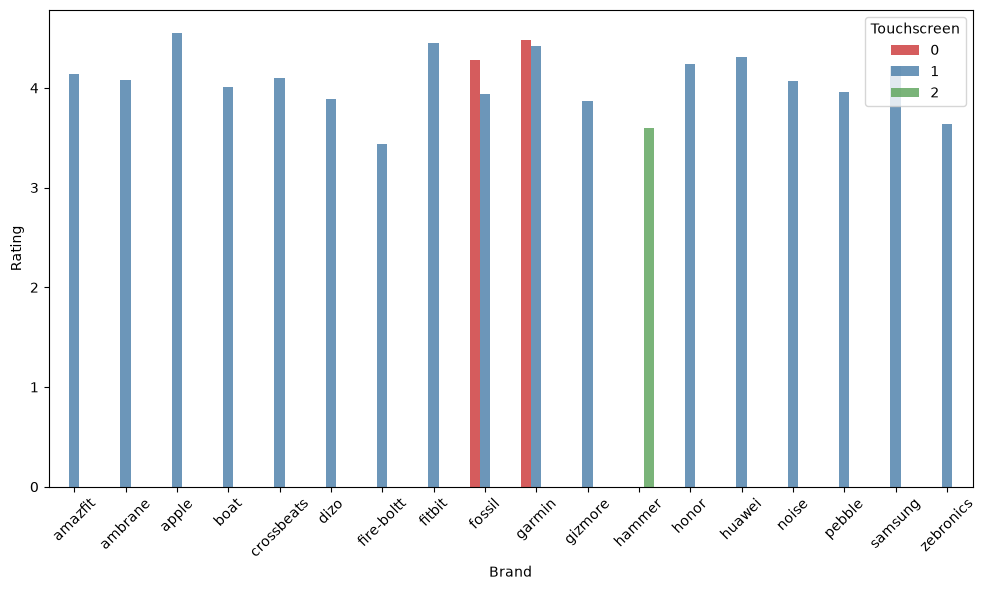

In [132]:
rating = data.groupby(['Brand','Touchscreen'])[['Rating']].mean()

plt.figure(figsize=(10,6))
sns.barplot(data = rating, x = 'Brand', y = 'Rating', hue = 'Touchscreen', 
                            palette = 'Set1', alpha = 0.8, width=0.6)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [133]:
data[data['Current Price'] < data['Original Price']]['Brand'].unique()

<StringArray>
[     'noise', 'fire-boltt',       'boat',      'honor', 'crossbeats',
    'samsung',     'garmin',     'huawei',       'dizo',    'gizmore',
    'ambrane',  'zebronics',     'pebble',     'hammer',      'apple',
     'fitbit',    'amazfit',     'fossil']
Length: 18, dtype: str

In [134]:
pricey = []

for i in data['Brand'].unique():
    if i not in data[data['Current Price'] < data['Original Price']]['Brand'].unique():
        pricey.append(i)

pricey

[]

In [135]:
data['Brand'].unique()

<StringArray>
[     'noise', 'fire-boltt',       'boat',      'honor', 'crossbeats',
    'samsung',     'garmin',     'huawei',       'dizo',    'gizmore',
    'ambrane',  'zebronics',     'pebble',     'hammer',      'apple',
     'fitbit',    'amazfit',     'fossil']
Length: 18, dtype: str

In [136]:
brand_avg_price = data.groupby('Brand')[['Current Price', 'Original Price']].mean()

fig = px.bar(data_frame = brand_avg_price, barmode='group')
fig.update_layout(
    width = 1000, bargap = 0.3
)

In [137]:
brand_avg_price[brand_avg_price["Current Price"]>brand_avg_price["Original Price"]]

,Current Price,Original Price
Brand,,
apple,43161.307692,32092.307692


<Axes: >

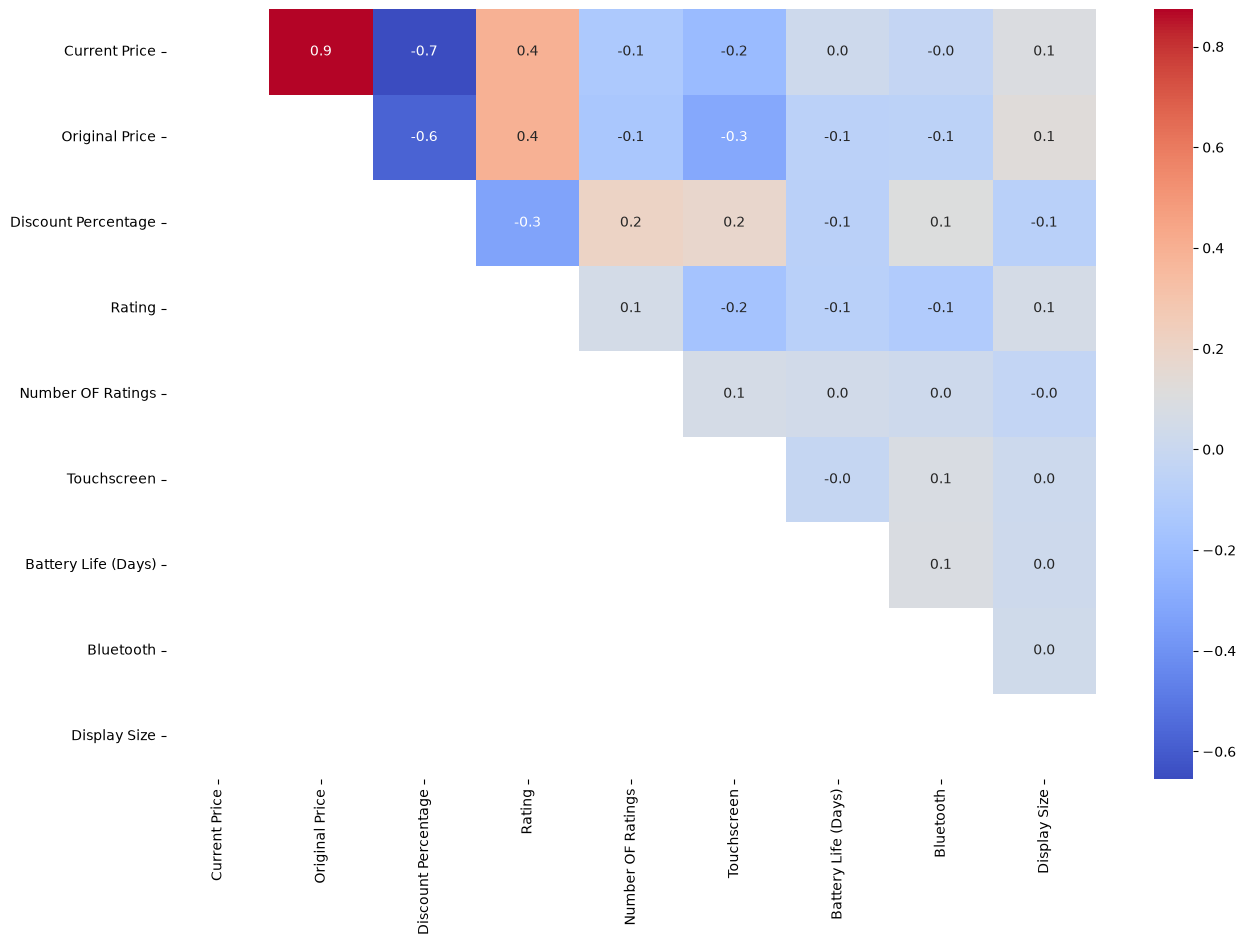

In [138]:
def mask_upper_triangle(matrix):
    mask = np.tri(matrix.shape[0], k=0, dtype=bool)
    matrix[mask] = np.nan
    return matrix

plt.figure(figsize=(15,10))

sns.heatmap(mask_upper_triangle(data.select_dtypes(include=np.number).corr()),
            annot = True, fmt=".1f", cmap='coolwarm')

> There is obviously a positive correlaltion between current price and original price, as opposed to that of the former and its discount percentage.

> What is noticeable from the chart is the negative association between the Original Price and the Discount Percentage. It can be deduced that the higher the orignal price of the product is, the less likely it is to be put on a significant discount and vice versa

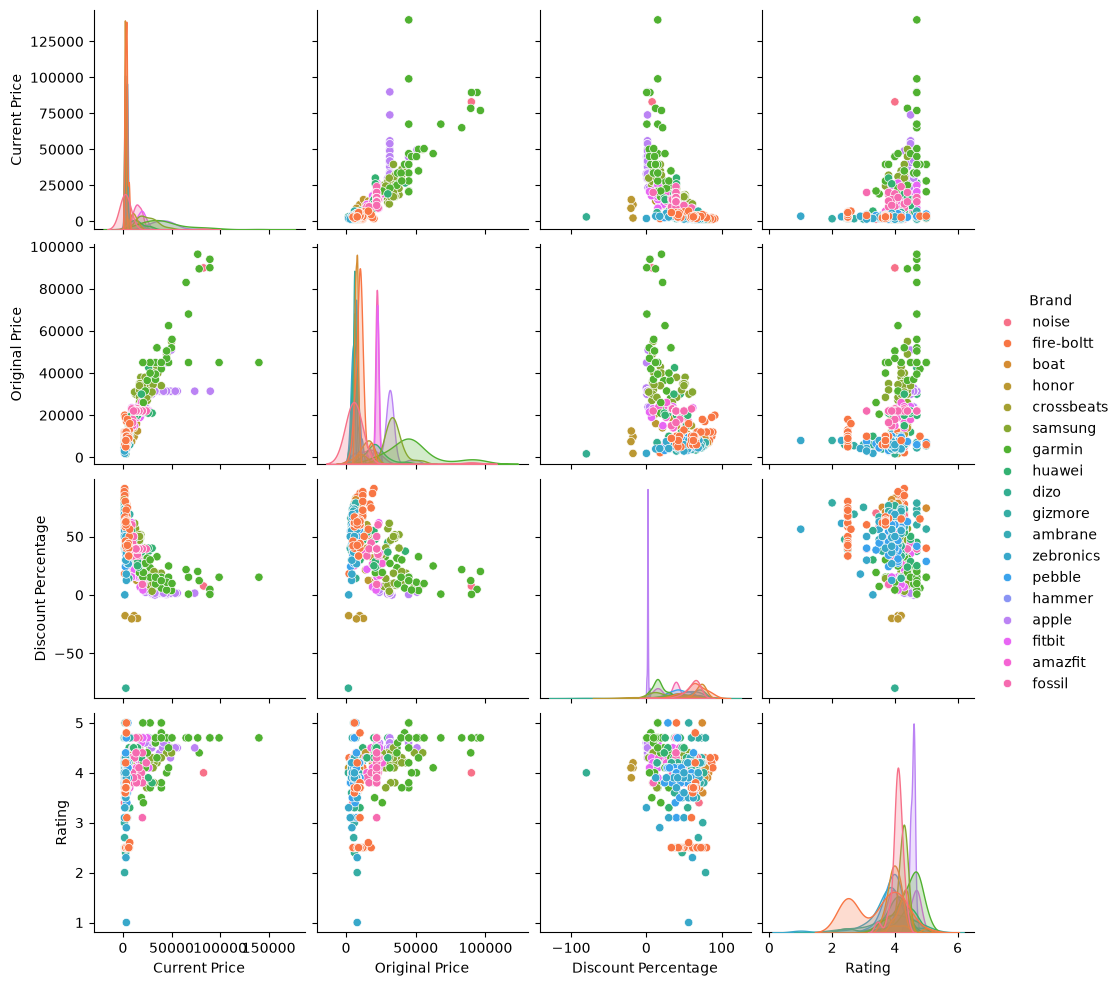

In [139]:
cols = ['Current Price','Original Price','Discount Percentage','Rating','Brand']

sns.pairplot(data[cols],hue='Brand')

In [140]:
weight=data.groupby("Weight")[["Current Price","Original Price"]].mean()

px.bar(data_frame=weight,barmode="group")

In [141]:
weight=data.groupby("Weight")["Rating"].mean().reset_index()

px.bar(data_frame=weight, x="Weight", y="Rating", color="Weight", 
             title="Average Rating by Weight", barmode="group")

<Axes: xlabel='Touchscreen', ylabel='Battery Life (Days)'>

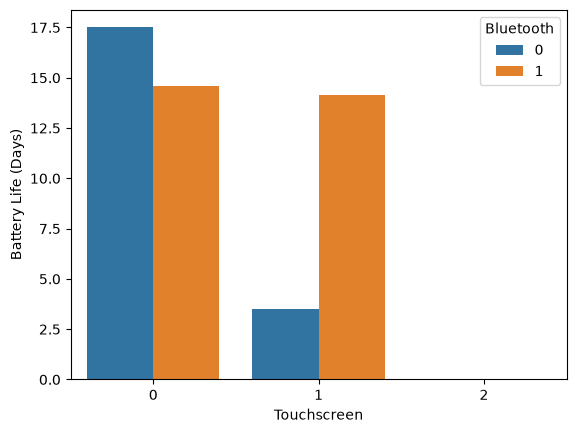

In [142]:
tb=data.groupby(["Touchscreen","Bluetooth"])[["Battery Life (Days)"]].mean()

sns.barplot(data=tb,x="Touchscreen",y="Battery Life (Days)",hue="Bluetooth")

>Battery life of smartwatches without touchscreen is significantly higher than that with one for those having built-in bluetooth, with the difference being approximately half a month. In contrast, for those integrating bluetooth function, the battery life shows relatively similar numbers among both smartphone types with and without touchscreen

In [143]:
tb=data.groupby(["Touchscreen","Bluetooth","Display Size"])[["Battery Life (Days)"]].mean()
tb

Battery Life (Days)
Touchscreen Bluetooth Display Size                     
0           0         0.8                     17.500000
            1         0.8                     17.500000
                      0.9                     15.916667
                      1.0                     22.000000
                      1.1                     11.166667
                      1.2                     15.833333
                      1.3                     15.083333
                      1.7                     17.500000
                      1.9                      8.000000
                      18.5                     3.500000
1           0         0.2                      3.500000
                      1.3                      3.500000
            1         0.0                     12.500000
                      0.1                     14.763889
                      0.2                     11.800000
                      0.5                      8.000000
                      0.6                     22.000000
                      1.0                     15.833333
                      1.1                     10.375000
                      1.2                     12.271739
                      1.3                     14.808772
                      1.4                     11.316667
                      1.5                     18.071429
                      1.6                     17.078125
                      1.7                     14.658784
                      1.8                     14.553279
                      1.9                     12.940909
                      2.0                     15.000000
                      2.1                     22.000000
                      2.3                     22.000000
                      2.4                      3.500000
                      2.7                     22.000000
                      3.0                      3.500000
                      3.3                     13.875000
                      3.5                     15.000000
                      4.0                      3.500000
                      4.2                     22.000000
                      4.3                     15.833333
                      4.4                      9.040000
                      4.5                      8.000000
                      4.6                      3.600000
                      6.9                      3.500000
                      15.9                    17.500000
                      20.0                     3.500000
                      27.9                    22.000000
                      30.0                     8.000000
                      33.0                    17.500000
                      35.9                    22.000000
                      45.0                    22.000000
2           1         1.8                           NaN

In [144]:
px.histogram(data_frame=data, x="Battery Life (Days)",)

In [145]:
summary_stats = data.groupby(
    ['Touchscreen', 'Bluetooth', 'Display Size']
    )['Battery Life (Days)'].agg(['mean', 'median', 'std']
    ).reset_index().sort_values("Display Size",ascending=False)
    
summary_stats

,Touchscreen,Bluetooth,Display Size,mean,median,std
48,1,1,45.0,22.000000,22.0,NaN
47,1,1,35.9,22.000000,22.0,0.000000
46,1,1,33.0,17.500000,17.5,NaN
45,1,1,30.0,8.000000,8.0,NaN
44,1,1,27.9,22.000000,22.0,NaN
43,1,1,20.0,3.500000,3.5,0.000000
9,0,1,18.5,3.500000,3.5,NaN
42,1,1,15.9,17.500000,17.5,NaN
41,1,1,6.9,3.500000,3.5,NaN
40,1,1,4.6,3.600000,3.6,NaN


### Feature Engineering & Preprocessing Pipeline

1. **Ordinal Encoding for `Weight`**: Map continuous interval midpoints to preserve ordinal density.
2. **Feature Separation**: Separate features $X$ and target $y$ (`Current Price`), explicitly excluding leaky attributes (`Original Price`, `Discount Percentage`) and high-cardinality identifiers (`Model Name`).
3. **Leak-Free Train-Test Split**: Partition $X$ and $y$ prior to fitting any scalers or encoders.
4. **Modular Preprocessing (`ColumnTransformer` + `SimpleImputer`)**:
   - **Numeric Features**: Impute missing values with `SimpleImputer(strategy='median')` and scale with `StandardScaler`.
   - **Categorical Features**: Impute missing values with `SimpleImputer(strategy='most_frequent')` and encode with `OneHotEncoder(handle_unknown='ignore')`.
5. **Target Log-Transformation**: Wrap regressors in `TransformedTargetRegressor` using $\log(1+y)$ to normalize right-skewed watch prices.

In [146]:
# 1. Create a clean working copy and map ordinal Weight classes to interval midpoints
df = data.copy()

weight_map = {
    '< 35 g': 25.0,
    '35 - 50 g': 42.5,
    '50 - 75 g': 62.5,
    '> 75 g': 85.0
}
df['Weight_Numeric'] = df['Weight'].map(weight_map)

# 2. Define Features X and Target y (Preventing Data Leakage)
features_to_drop = ['Current Price', 'Original Price', 'Discount Percentage', 'Model Name', 'Weight']
X = df.drop(columns=[col for col in features_to_drop if col in df.columns])
y = df['Current Price'].copy()

# Filter valid records where target is non-null
valid_idx = y.notna()
X = X.loc[valid_idx].copy()
y = y.loc[valid_idx].copy()

num_features = ['Display Size', 'Rating', 'Number OF Ratings', 'Battery Life (Days)', 'Weight_Numeric', 'Touchscreen', 'Bluetooth']
cat_features = ['Brand', 'Dial Shape', 'Strap Material', 'Strap Color']

# Retain only columns that exist in X
num_features = [f for f in num_features if f in X.columns]
cat_features = [f for f in cat_features if f in X.columns]

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
X.head()

Feature matrix X shape: (440, 11)
Target vector y shape: (440,)


,Brand,Rating,Number OF Ratings,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight_Numeric
0,noise,4.0,65.0,Rectangle,Black,Other,1,8.0,1,1.7,42.5
1,fire-boltt,4.3,20788.0,Square,Black,Silicon,1,3.5,1,1.8,62.5
2,boat,3.8,21724.0,Rectangle,Black,Silicon,1,8.0,1,1.7,42.5
3,fire-boltt,4.3,13244.0,Square,Black,Silicon,1,3.5,1,1.8,NaN
4,noise,4.1,13901.0,Rectangle,Black,Other,1,8.0,1,1.7,42.5


#### Leak-Free Train-Test Split & Robust Preprocessing Pipeline

In [147]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Robust Numerical Transformer: Impute NaNs -> Scale
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Robust Categorical Transformer: Impute NaNs -> OneHotEncode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Assemble Preprocessing ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Training set: 352 samples
Testing set:  88 samples


#### Model Training & Multi-Model Benchmarking

In [148]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42)
}

results = []
trained_pipelines = {}
predictions = {}

for name, model in models.items():
    # Log-target transformed pipeline
    ttr = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', ttr)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'RMSE (₹)': round(rmse, 2),
        'MAE (₹)': round(mae, 2),
        'R2 Score': round(r2, 4)
    })
    trained_pipelines[name] = pipeline
    predictions[name] = y_pred

model_comparison = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
model_comparison

,Model,RMSE (₹),MAE (₹),R2 Score
0,Gradient Boosting,13168.62,5409.20,0.5523
1,Random Forest,13661.59,5341.34,0.5181
2,Ridge Regression,13969.17,5562.21,0.4962
3,Linear Regression,14390.46,5807.47,0.4653
4,Decision Tree,14401.60,6183.16,0.4645
5,AdaBoost,15037.82,6896.59,0.4162


#### Model Comparison Visualizations

In [149]:
import plotly.express as px

fig = px.bar(
    model_comparison,
    x='Model',
    y='R2 Score',
    color='R2 Score',
    title='Model Comparison: R² Score across Regressors',
    text_auto='.3f',
    template='plotly_white'
)
fig.show()

#### Best Model Inspection & Feature Importance

In [150]:
# Extract Random Forest regressor and feature names from the fitted preprocessor
rf_pipeline = trained_pipelines['Random Forest']
fitted_preprocessor = rf_pipeline.named_steps['preprocessor']
rf_model = rf_pipeline.named_steps['regressor'].regressor_

ohe_cat_features = fitted_preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_features)
all_feature_names = list(num_features) + list(ohe_cat_features)

feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Top 15 most important features
top_features = feature_importance.head(15)

fig_imp = px.bar(
    top_features,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Top 15 Feature Importances (Random Forest)',
    template='plotly_white',
    color='Importance'
)
fig_imp.update_layout(yaxis={'categoryorder': 'total ascending'})
fig_imp.show()

#### Actual vs. Predicted Price Evaluation

In [151]:
best_model_name = model_comparison.iloc[0]['Model']
best_preds = predictions[best_model_name]

eval_df = pd.DataFrame({
    'Actual Price (₹)': y_test.values,
    'Predicted Price (₹)': np.round(best_preds, 2),
    'Absolute Error (₹)': np.round(np.abs(y_test.values - best_preds), 2),
    'Percentage Error (%)': np.round(np.abs(y_test.values - best_preds) / (y_test.values + 1e-5) * 100, 2)
})

print(f"--- Actual vs Predicted Price using {best_model_name} (Sample 10) ---")
eval_df.head(10)

--- Actual vs Predicted Price using Gradient Boosting (Sample 10) ---


,Actual Price (₹),Predicted Price (₹),Absolute Error (₹),Percentage Error (%)
0,64990.0,42002.54,22987.46,35.37
1,2368.0,2505.32,137.32,5.80
2,1799.0,1315.61,483.39,26.87
3,33490.0,42618.58,9128.58,27.26
4,1199.0,2633.38,1434.38,119.63
5,13195.0,13345.97,150.97,1.14
6,22749.0,23414.09,665.09,2.92
7,1799.0,2291.43,492.43,27.37
8,3200.0,3190.44,9.56,0.30
9,2299.0,3999.47,1700.47,73.97


In [152]:
# Scatter plot: Actual vs Predicted Price with Ideal Diagonal Reference Line
fig_eval = px.scatter(
    eval_df,
    x='Actual Price (₹)',
    y='Predicted Price (₹)',
    title=f'Actual vs. Predicted Price ({best_model_name})',
    template='plotly_white',
    hover_data=['Percentage Error (%)']
)

# Add perfect prediction reference line (y = x)
max_val = max(eval_df['Actual Price (₹)'].max(), eval_df['Predicted Price (₹)'].max())
fig_eval.add_shape(
    type='line',
    x0=0, y0=0, x1=max_val, y1=max_val,
    line=dict(color='red', dash='dash'),
)
fig_eval.show()